# Running PATH

In [9]:
from frb.surveys import survey_utils as su

from astropy.coordinates import SkyCoord
from astropy import units as u, visualization as vis
from astropy.wcs import WCS, utils as wcsutils
from astropy.stats import sigma_clipped_stats

from astropath import path

import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 16

from photutils.aperture import SkyEllipticalAperture

%matplotlib inline

## FRB localization

In [2]:
# Define the FRB coordinates
frb_coord = SkyCoord(334.019875, -7.89825, unit="deg")

# Define the error ellipse parameters
eellipse = {
        "a": 0.38, # a and b are in arcsec
        "b": 0.35,
        "theta": 90.0, # PA is in degrees
    }

## Download image

In [4]:
# Load the survey class
survey = su.load_survey_by_name("DECaL", coord = frb_coord, radius = 1*u.arcmin)
imghdu = survey.get_image(imsize=2*u.arcmin, band="r")

downloading deepest stacked image...


## Download catalog

In [5]:
# Download image source catalogs
cat = survey.get_catalog(query_fields=['shape_r'])
galaxies = cat[cat['DECaL_type']!='PSF']
galaxies

z_phot_median,z_spec,survey,z_phot_l68,z_phot_u68,z_phot_l95,z_phot_u95,DECaL_brick,dec,DECaL_ID,DECaL_g,DECaL_r,DECaL_z,ra,shape_r,DECaL_g_err,DECaL_r_err,DECaL_z_err,DECaL_type
float64,float64,str4,float64,float64,float64,float64,int64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,str3
0.35399604,-99.0,-99.,0.3363716,0.3926779,0.32399905,0.4405101,285734,-7.913617329588269,10995415891580510,22.063986,20.385353,19.502876,334.0164200684941,0.51049924,0.019353345540576918,0.007878665789271695,0.007270302332802027,REX
0.7047726,-99.0,-99.,0.54445976,0.98648816,0.4182722,2.0551333,285734,-7.912399036260708,10995415891580528,25.153933,23.85085,23.272755,334.0172055294415,0.22094311,0.22540462516177237,0.129896408763736,0.16175115673130458,REX
0.700138,-99.0,-99.,0.46751618,0.83084047,0.28935868,1.0824728,285734,-7.910726376122932,10995415891580522,23.679369,23.111647,22.525122,334.0170929026659,0.46962202,0.06948650305355783,0.07424140758095576,0.0928567767194137,EXP
0.93656194,-99.0,-99.,0.80375564,1.0965636,0.6668401,1.2204353,285734,-7.909386669728841,10995415891580568,23.9049,23.373648,22.363537,334.018804305721,0.34026554,0.08450423840833671,0.12372317779404232,0.0804216098816295,REX
0.42018616,-99.0,-99.,0.36784434,0.46964785,0.34241748,0.5323175,285734,-7.907928855018775,10995415891580287,23.105824,21.35383,20.404242,334.0075270281061,0.2687194,0.042778365363912545,0.015310106838470781,0.01327871910467549,REX
0.6844163,-99.0,-99.,0.46763775,0.8544722,0.31341335,1.1162641,285734,-7.90538578916595,10995415891580264,23.983868,23.29111,22.655928,334.0062785333772,0.4451506,0.10494882314890118,0.09330016168223709,0.11356734739826349,REX
0.9267012,-99.0,-99.,0.63164353,1.1270238,0.44667277,1.40174,285734,-7.905256712416152,10995415891580281,25.06918,24.39642,23.434315,334.0072372241258,0.28828624,0.2339384573747202,0.21569616711814885,0.19512731537770553,REX
0.84011346,-99.0,-99.,0.76036996,0.9317673,0.6848966,1.0559857,285734,-7.896796985887639,10995415891580217,24.728983,23.18276,21.410593,334.0047317718544,0.77033556,0.20720372198520517,0.09396771479015745,0.039630294263222496,EXP
0.4144358,-99.0,-99.,0.37784594,0.45494696,0.29595047,0.5074964,285734,-7.897265313912635,10995415891580249,22.012926,20.873713,20.223047,334.0058267740081,0.5970275,0.02109688216907795,0.012515168956916983,0.014693280665492357,REX


### Visualize sources

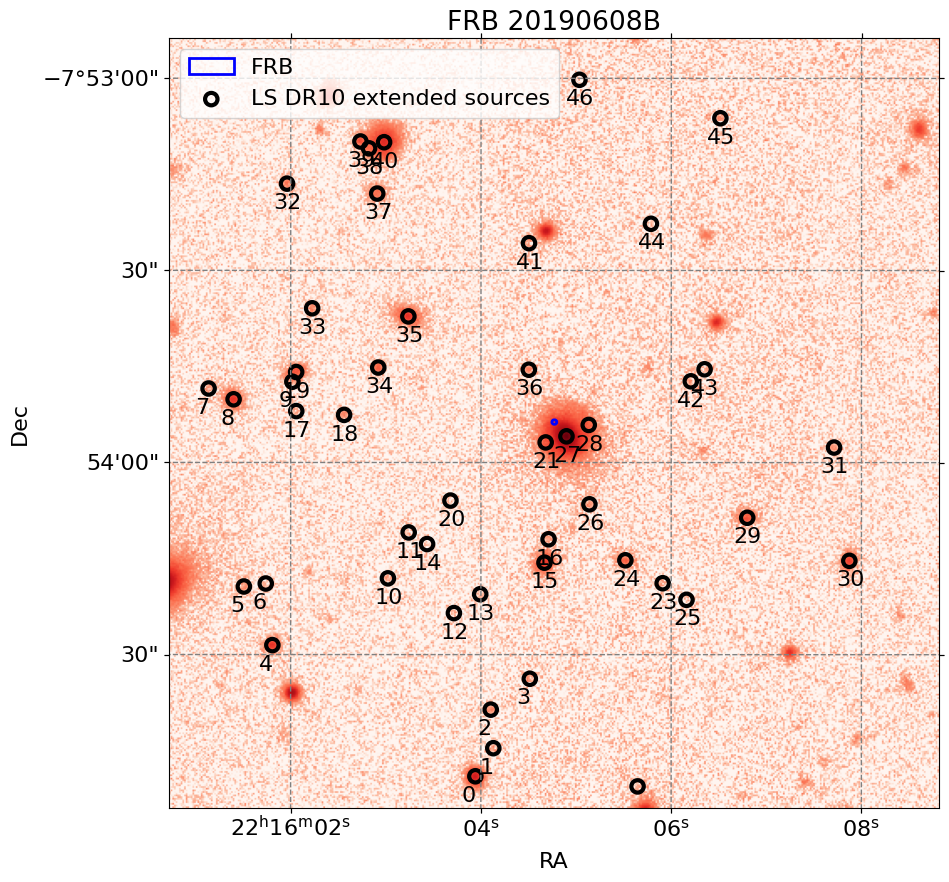

In [6]:
# Prepare for visualization
data, header = imghdu.data, imghdu.header
_, med, std = sigma_clipped_stats(data)
norm = vis.ImageNormalize(stretch = vis.LogStretch(), vmin = med, vmax = med + 200*std)
wcs = WCS(header)
ell_aper = SkyEllipticalAperture(frb_coord, a = eellipse['a']*u.arcsec, b = eellipse['b']*u.arcsec, theta = eellipse['theta']*u.deg) 
fig, ax = plt.subplots(1, 1, figsize = (10, 10), subplot_kw={"projection":wcs})

# Visualize
## First the image itself
ax.imshow(data, norm = norm, cmap = "Reds")
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("FRB 20190608B")
ax.grid(color="grey", lw=1, ls="--")

## Then, the FRB
pix_aper = ell_aper.to_pixel(wcs)
pix_aper.plot(ax, color = "b", lw = 2, label="FRB")


## Finally, the catalog sources
ax.scatter(galaxies['ra'], galaxies['dec'],
           transform=ax.get_transform('icrs'),
           c = 'None', s=80, marker="o", edgecolor="k", lw=3,
           label="LS DR10 extended sources")
### Number them
x,y = wcsutils.skycoord_to_pixel(SkyCoord(galaxies['ra'], galaxies['dec'], unit="deg"), wcs)
for num, entry in enumerate(galaxies):
    ax.annotate(str(num), (x[num]-8, y[num]-15), color="k")

ax.legend()
plt.show()

# PATH

## Initialize localization

In [10]:
Path = path.PATH()

In [11]:
Path.init_localization('eellipse', center_coord=frb_coord, eellipse=eellipse)

### Prepare candidate galaxies for testing

In [16]:
path_cat = galaxies[['DECaL_ID', 'ra', 'dec', 'shape_r', 'DECaL_r']]
path_cat.rename_columns(['DECaL_ID', 'shape_r', 'DECaL_r'], ['id', 'r_e', 'r_mag'])
path_cat

id,ra,dec,r_e,r_mag
int64,float64,float64,float64,float64
10995415891580510,334.0164200684941,-7.913617329588269,0.51049924,20.385353
10995415891580528,334.0172055294415,-7.912399036260708,0.22094311,23.85085
10995415891580522,334.0170929026659,-7.910726376122932,0.46962202,23.111647
10995415891580568,334.018804305721,-7.909386669728841,0.34026554,23.373648
10995415891580287,334.0075270281061,-7.907928855018775,0.2687194,21.35383
10995415891580264,334.0062785333772,-7.90538578916595,0.4451506,23.29111
10995415891580281,334.0072372241258,-7.905256712416152,0.28828624,24.39642
10995415891580217,334.0047317718544,-7.896796985887639,0.77033556,23.18276
10995415891580249,334.0058267740081,-7.897265313912635,0.5970275,20.873713


In [19]:
# Write it to a CSV file for manual examination later if needed
outfile = "../data/FRB20190608B_DECaL_PATH.csv"
path_cat.write(outfile, overwrite=True)

In [20]:
# Initialize candidates
Path.init_candidates(ra = path_cat['ra'].data, # degrees
                     dec = path_cat['dec'].data, # degrees
                     ang_size = path_cat['r_e'].data, # arcsec
                     mag=path_cat['r_mag'].data) # mag

## Priors

In [22]:
# Candidate prior for the magnitudes
Path.init_cand_prior(P_O_method = 'inverse', P_U = 0.15)

# Offset prior
Path.init_theta_prior(PDF = 'exp', max = 6., scale = 0.5)

p_O = Path.calc_priors()

## Extract posteriors

In [27]:
# Set boxsize accoring to the largest galaxy (arcsec)
box_hwidth = max(10*eellipse['a'], 10*np.nanmax(path_cat['r_e']))

# Set step size
step_size_max = 2*3*eellipse['b']/np.nanmax(path_cat['r_e'])
step_size = min([0.1, step_size_max])

P_Ox, P_Ux = Path.calc_posteriors(method = 'local',
                                  box_hwidth = box_hwidth,
                                  max_radius = box_hwidth,
                                  step_size = step_size)

# Add it to the table
path_cat['P_Ox'] = P_Ox

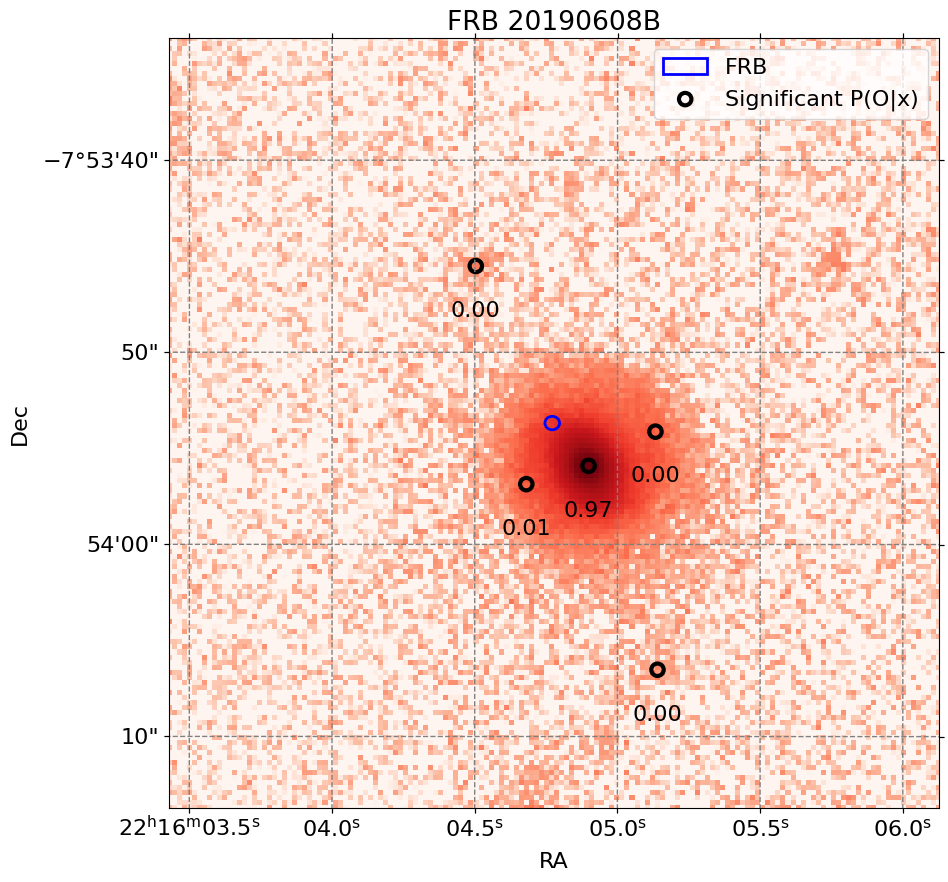

In [37]:
# Visualize again but with PATH posteriors


# Prepare for visualization
data, header = imghdu.data, imghdu.header
_, med, std = sigma_clipped_stats(data)
norm = vis.ImageNormalize(stretch = vis.LogStretch(), vmin = med, vmax = med + 200*std)
wcs = WCS(header)
ell_aper = SkyEllipticalAperture(frb_coord, a = eellipse['a']*u.arcsec, b = eellipse['b']*u.arcsec, theta = eellipse['theta']*u.deg) 
fig, ax = plt.subplots(1, 1, figsize = (10, 10), subplot_kw={"projection":wcs})

# Visualize
## First the image itself
ax.imshow(data, norm = norm, cmap = "Reds")
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("FRB 20190608B")
ax.grid(color="grey", lw=1, ls="--")

## Then, the FRB
pix_aper = ell_aper.to_pixel(wcs)
pix_aper.plot(ax, color = "b", lw = 2, label="FRB")


## Finally, the catalog sources
non_zero_path = path_cat[path_cat['P_Ox']>0]

ax.scatter(non_zero_path['ra'], non_zero_path['dec'],
           transform=ax.get_transform('icrs'),
           c = 'None', s=80, marker="o", edgecolor="k", lw=3,
           label="Significant P(O|x)")
### Number them
x,y = wcsutils.skycoord_to_pixel(SkyCoord(non_zero_path['ra'], non_zero_path['dec'], unit="deg"), wcs)
for num, entry in enumerate(non_zero_path):
    ax.annotate(f"{entry['P_Ox']:0.2f}", (x[num]-5, y[num]-10), color="k")

ax.legend()
ax.set_ylim(data.shape[1]/3, data.shape[1]*2/3)
ax.set_xlim(data.shape[0]/3, data.shape[0]*2/3)
plt.show()